# 05 — Pipeline de dados: scraping, limpeza e o gargalo do dataset

> Base: paper `constuir gptr.pdf`, §6 ("Pipeline de dados") + Listing 5 (TextDataset).
> Objetivo: montar o caminho que leva de *texto bruto na Wikipedia* até *tensores
> de tokens prontos para o treino* — e entender por que a decisão mais barata desse
> caminho (o `stride` do dataset) foi a que mais acelerou o projeto.

Depois de saber *o que* o modelo calcula (nbs 01–04), falta o combustível: dados.
Este notebook cobre a coleta, a limpeza, o empacotamento em janelas de contexto e
o cache. O achado central do capítulo — e uma das lições mais úteis do paper — é
que **o gargalo de tempo raramente está onde você imagina**: aqui não era a GPU
nem a arquitetura, era o *dataloader*.

**O que você vai sair sabendo:**
1. Como estruturar scraping robusto (rate limit, `Retry-After`) e por que inglês.
2. Limpar texto de Wikipedia de forma componível e à prova de coluna faltante.
3. A diferença entre *sliding window* (stride 1) e *chunked* (stride = T_ctx) — e
   por que a segunda dá ~124× menos steps por época **sem** perder qualidade.
4. O ciclo de vida do cache de tokens e o *pitfall* silencioso da invalidação.

> Este notebook alimenta os stubs `src/tucanoce/data/scrape.py` (coleta + limpeza) e
> `src/tucanoce/data/dataset.py` (o `TextDataset` com `stride`).

In [1]:
import os, re, json, time, hashlib, tempfile
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

# Convenção visual do projeto (idêntica ao nb 00).
plt.rcParams.update({
    "figure.figsize": (6, 4), "figure.dpi": 100,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})
torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.12.1+cpu


## 1. Scraping: por que inglês, e como coletar sem apanhar do servidor

O corpus do paper vem de artigos da Wikipedia **em inglês**, selecionados por
categorias de física (`Particle_physics`, `Quantum_field_theory`, `Astrophysics`,
`Black_holes`, …). A escolha do inglês é deliberada: para física técnica a
Wikipedia inglesa tem profundidade e densidade muito maiores que a portuguesa, o
que serve melhor ao objetivo de testar a arquitetura num **domínio denso**.

Cada artigo é baixado via MediaWiki API (`prop=extracts&explaintext=true`, que já
devolve texto plano sem HTML) e vira uma linha JSONL:

```json
{"text": "...", "title": "Quark", "source": "wikipedia", "category": "Particle_physics"}
```

O formato JSONL (uma linha = um artigo) é escolhido porque permite **agregar
múltiplas fontes** no futuro sem reescrever nada: basta concatenar arquivos.

### Robustez (§6.1.2): a parte que separa um scraper de brinquedo de um de produção
A API tolera leituras frequentes, mas dispara **HTTP 429 (Too Many Requests)**
acima de certo ritmo. Duas decisões importam:

- **Rate limit fixo** de Δt ≥ 1,5 s entre requisições (abaixo do limite documentado
  de ~200 req/min). Um Δt = 0,5 s ingênuo levou a 429 após algumas centenas de chamadas.
- **Respeitar o cabeçalho `Retry-After`** que o servidor devolve no 429 — ele diz
  *exatamente* quanto esperar. Isso é melhor que backoff exponencial cego: você não
  espera nem de menos (leva outro 429) nem de mais (desperdiça tempo).

In [2]:
import urllib.request  # (no código real do paper usa-se `requests`; stdlib aqui p/ não exigir dep)

RUN_SCRAPE = False   # <- deixamos DESLIGADO: este notebook roda sem rede.

WIKI_API = "https://en.wikipedia.org/w/api.php"
MIN_INTERVAL = 1.5   # segundos entre requisições (§6.1.2)

def fetch_article_text(title: str, session_last_call: list) -> str | None:
    """Baixa o texto plano de UM artigo, respeitando rate limit e Retry-After.

    session_last_call: lista de 1 elemento com o timestamp da última chamada
    (mutável p/ manter estado entre chamadas sem variável global).
    """
    # --- rate limit fixo: nunca chamar mais rápido que MIN_INTERVAL ---
    wait = MIN_INTERVAL - (time.monotonic() - session_last_call[0])
    if wait > 0:
        time.sleep(wait)

    params = {
        "action": "query", "format": "json", "prop": "extracts",
        "explaintext": "true", "titles": title, "redirects": "1",
    }
    url = WIKI_API + "?" + "&".join(f"{k}={v}" for k, v in params.items())

    for attempt in range(5):
        try:
            with urllib.request.urlopen(url, timeout=30) as resp:
                session_last_call[0] = time.monotonic()
                data = json.loads(resp.read())
            pages = data["query"]["pages"]
            page = next(iter(pages.values()))
            return page.get("extract")  # None se a página não existe
        except urllib.error.HTTPError as e:
            if e.code == 429:
                # --- respeita Retry-After; fallback = 30s (§6.1.2) ---
                retry_after = int(e.headers.get("Retry-After", 30))
                time.sleep(max(retry_after, 30))
                continue
            raise
    return None

# Demonstração SEM rede: um "artigo" mock que fingimos ter baixado.
if RUN_SCRAPE:
    txt = fetch_article_text("Quark", session_last_call=[0.0])
else:
    txt = None
    print("RUN_SCRAPE=False -> nada de rede. Seguimos com corpus mock inline.")

RUN_SCRAPE=False -> nada de rede. Seguimos com corpus mock inline.


## 2. Limpeza: funções pequenas, componíveis e tolerantes

O texto bruto traz lixo que não tem valor educacional: seções de `References`,
`External links`, `See also`, `Further reading`, marcadores de citação `[1]`,
`[2]`, e excesso de quebras de linha. A limpeza (§6.1.1) é uma sequência de
transformações **puras** — cada uma faz uma coisa e pode ser testada sozinha —, e
artigos muito curtos (*stubs* < 300 chars após limpeza) são descartados.

> Padrão herdado do blueprint (seção 3): funções pequenas e componíveis, com
> "degradação graciosa" — se uma seção não existe no artigo, a função simplesmente
> não faz nada em vez de quebrar.

In [3]:
# Seções cujo TÍTULO exato marca o fim do conteúdo útil (§6.1.1).
DROP_SECTIONS = ("References", "External links", "See also", "Further reading",
                 "Notes", "Bibliography")

def strip_trailing_sections(text: str) -> str:
    """Corta o texto a partir do primeiro cabeçalho de seção sem valor.

    Extracts da MediaWiki marcam seções como '== Título ==' (níveis com mais '=').
    Cortamos na primeira ocorrência de uma seção da lista.
    """
    lines = text.split("\n")
    for i, line in enumerate(lines):
        heading = line.strip().strip("=").strip()  # '== References ==' -> 'References'
        if line.strip().startswith("==") and heading in DROP_SECTIONS:
            return "\n".join(lines[:i])
    return text  # nenhuma seção-lixo encontrada: degradação graciosa

def remove_ref_markers(text: str) -> str:
    """Remove marcadores numéricos de citação: [1], [12], [3][4]..."""
    return re.sub(r"\[\d+\]", "", text)

def collapse_blank_lines(text: str) -> str:
    """Colapsa 3+ quebras de linha consecutivas em exatamente 2."""
    return re.sub(r"\n{3,}", "\n\n", text)

def clean_article(text: str, min_chars: int = 300) -> str | None:
    """Pipeline de limpeza. Retorna None para stubs (curtos demais)."""
    text = strip_trailing_sections(text)
    text = remove_ref_markers(text)
    text = collapse_blank_lines(text)
    text = text.strip()
    return text if len(text) >= min_chars else None

In [4]:
# Teste em um artigo "sujo" mock, com asserts (§6.1.1).
dirty = (
    "Quarks are elementary particles[1] and a fundamental constituent of matter[2].\n\n\n\n"
    "There are six types, known as flavors[3]: up, down, charm, strange, top, and bottom.\n"
    "Quarks combine to form composite particles called hadrons, the most stable of "
    "which are protons and neutrons. Owing to a phenomenon known as color confinement, "
    "quarks are never directly observed or found in isolation.\n\n"
    "== References ==\n"
    "[1] Wikipedia contributors.\n[2] Particle Data Group.\n"
    "== External links ==\n"
    "Quark model on Encyclopedia Britannica.\n"
)

clean = clean_article(dirty)
print(clean)
print("-" * 60)

assert "== References ==" not in clean, "seção References deveria ter sido cortada"
assert "External links" not in clean,   "seção External links deveria ter sumido junto"
assert "[1]" not in clean and "[3]" not in clean, "marcadores [n] deveriam sumir"
assert "\n\n\n" not in clean, "3+ quebras deveriam colapsar em 2"
# stub: um texto curtinho vira None
assert clean_article("too short") is None, "stub < 300 chars deveria virar None"
print("OK — todos os asserts de limpeza passaram.")

Quarks are elementary particles and a fundamental constituent of matter.

There are six types, known as flavors: up, down, charm, strange, top, and bottom.
Quarks combine to form composite particles called hadrons, the most stable of which are protons and neutrons. Owing to a phenomenon known as color confinement, quarks are never directly observed or found in isolation.
------------------------------------------------------------
OK — todos os asserts de limpeza passaram.


## 3. Do texto aos tokens: o corpus vira um `LongTensor`

Depois de limpar, cada artigo é tokenizado (nb 02) e todos os tokens são
**concatenados num único fluxo** de inteiros. Um token especial `<|endoftext|>`
(aqui simulado pelo id `0`) separa artigos, sinalizando fronteira de documento.

Para este notebook rodar sem depender do tokenizer BPE real, usamos um
tokenizador de brinquedo (bytes UTF-8) sobre um corpus mock — o que importa aqui é
a **forma** do dado (um vetor 1-D longo de ids), não os ids em si.

In [5]:
# Corpus mock: 3 "artigos" de física. Em produção, viriam do JSONL limpo.
mock_corpus = [
    "Quarks combine to form hadrons such as protons and neutrons.",
    "General relativity describes gravity as the curvature of spacetime.",
    "In quantum field theory, particles are excitations of underlying fields.",
]

EOT = 0  # id do <|endoftext|>; tokens reais começam em 1 p/ não colidir

def toy_encode(text: str) -> list[int]:
    """Tokenizador de brinquedo: cada byte UTF-8 vira um id (deslocado de +1)."""
    return [b + 1 for b in text.encode("utf-8")]

# Concatena os artigos num único fluxo, com EOT entre eles.
stream = []
for art in mock_corpus:
    stream.extend(toy_encode(art))
    stream.append(EOT)

tokens = torch.tensor(stream, dtype=torch.long)
print("nº de tokens no corpus mock:", tokens.numel())
print("primeiros 20 ids:", tokens[:20].tolist())
print("dtype:", tokens.dtype, "(int64 — LongTensor, o que a Embedding espera)")

nº de tokens no corpus mock: 202
primeiros 20 ids: [82, 118, 98, 115, 108, 116, 33, 100, 112, 110, 99, 106, 111, 102, 33, 117, 112, 33, 103, 112]
dtype: torch.int64 (int64 — LongTensor, o que a Embedding espera)


## 4. O gargalo escondido: `sliding window` vs `chunked` (§6.2)

Aqui está a lição mais valiosa do capítulo. Para treinar um LM, quebramos o fluxo
de tokens em janelas de tamanho `context_len` ($T_{ctx}$). A pergunta é: **de
quanto em quanto** começamos uma nova janela? Esse passo é o `stride`.

**Sliding window (stride = 1):** uma janela por posição. Gera
$$ |\mathcal{D}| = N - T_{ctx} \quad\text{amostras} $$
Cada token aparece em $T_{ctx}$ amostras distintas (uma por posição relativa).

**Chunked (stride = $T_{ctx}$):** janelas sem sobreposição. Gera
$$ |\mathcal{D}|_{\text{chunked}} = \left\lfloor \frac{N-1}{T_{ctx}} \right\rfloor \quad\text{amostras} $$
Cada token aparece em **exatamente uma** amostra por época.

A razão entre os dois é ≈ $T_{ctx}$. No paper, com $T_{ctx} = 512$, isso significava
~360 mil steps/época (sliding) contra ~700 (chunked) — a diferença entre um treino
inviável (>24 h/época) e um de minutos. E o mais importante: **sem perda mensurável
de qualidade**, porque o modelo continua vendo o mesmo conteúdo, só distribuído em
menos steps. É o padrão de GPT-2, LLaMA e praticamente todo modelo moderno.

> Por que sliding não vale a pena: as janelas quase-idênticas (deslocadas de 1
> token) são altamente redundantes. Você paga $T_{ctx}$× mais compute para ver
> quase a mesma coisa. O `stride = 1` só sobrevive como opção para *ablations*.

In [6]:
class TextDataset(Dataset):
    """Dataset de janelas de contexto com stride configurável (Listing 5, §6.2).

    stride=None  -> chunked (stride = context_len), o default de produção.
    stride=1     -> sliding window, só para ablações.

    Cada item é um par (x, y) onde y é x deslocado por 1 token: o alvo da posição
    t é o token t+1. É o "next-token prediction" construído no próprio dataset.
    """
    def __init__(self, tokens, context_len: int, stride: int | None = None):
        self.tokens = tokens
        self.context_len = context_len
        self.stride = stride if stride is not None else context_len

    def __len__(self):
        if len(self.tokens) < self.context_len + 1:
            return 0
        # +1 porque precisamos de context_len+1 tokens (x e o y deslocado)
        return (len(self.tokens) - self.context_len - 1) // self.stride + 1

    def __getitem__(self, idx):
        start = idx * self.stride
        x = self.tokens[start: start + self.context_len]
        y = self.tokens[start + 1: start + self.context_len + 1]
        return (torch.tensor(x, dtype=torch.long) if not torch.is_tensor(x) else x,
                torch.tensor(y, dtype=torch.long) if not torch.is_tensor(y) else y)

In [7]:
T_ctx = 8  # context_len pequeno p/ enxergar a conta
N = tokens.numel()

ds_sliding = TextDataset(tokens, context_len=T_ctx, stride=1)
ds_chunked = TextDataset(tokens, context_len=T_ctx)   # stride = T_ctx (default)

print(f"N = {N} tokens, T_ctx = {T_ctx}")
print(f"sliding (stride=1):    {len(ds_sliding):3d} amostras   (= N - T_ctx = {N - T_ctx})")
print(f"chunked (stride={T_ctx}):    {len(ds_chunked):3d} amostras   (~ floor((N-1)/T_ctx) = {(N-1)//T_ctx})")
razao = len(ds_sliding) / len(ds_chunked)
print(f"razão sliding/chunked = {razao:.1f}x  (esperado ~ T_ctx = {T_ctx})")

# A __len__ do Listing 5 é (N - ctx - 1)//stride + 1 — mais conservadora que a
# fórmula simplificada floor((N-1)/T_ctx) do paper (garante x e y sem estourar).
assert len(ds_sliding) == (N - T_ctx - 1) // 1 + 1 == N - T_ctx
assert len(ds_chunked) == (N - T_ctx - 1) // T_ctx + 1
assert abs(razao - T_ctx) < 2.0, "razão deveria ficar próxima de T_ctx"
print("OK — |D| bate com a __len__ do Listing 5; razão ~ T_ctx.")

N = 202 tokens, T_ctx = 8
sliding (stride=1):    194 amostras   (= N - T_ctx = 194)
chunked (stride=8):     25 amostras   (~ floor((N-1)/T_ctx) = 25)
razão sliding/chunked = 7.8x  (esperado ~ T_ctx = 8)
OK — |D| bate com a __len__ do Listing 5; razão ~ T_ctx.


As barras deixam a conta visível: **sliding** gera ~$T_{ctx}$× mais amostras que
**chunked** para o *mesmo* corpus. Cada amostra a mais é um step de gradiente a
mais por época — e, como as janelas do sliding se sobrepõem quase inteiras, é
compute gasto vendo quase a mesma coisa. Foi essa razão (≈512 no paper) que separou
um treino de minutos de um de mais de 24 h por época.

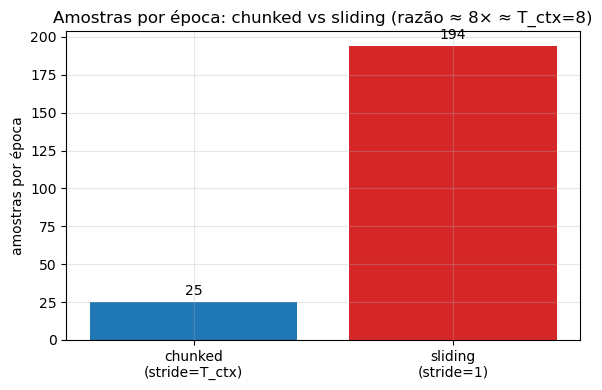

In [8]:
fig, ax = plt.subplots()
modos = ["chunked\n(stride=T_ctx)", "sliding\n(stride=1)"]
qtds = [len(ds_chunked), len(ds_sliding)]
bars = ax.bar(modos, qtds, color=["C0", "C3"])
ax.bar_label(bars, padding=3)
ax.set_ylabel("amostras por época")
ax.set_title(f"Amostras por época: chunked vs sliding (razão ≈ {razao:.0f}× ≈ T_ctx={T_ctx})")
plt.tight_layout(); plt.show()

Por que a diferença? A figura abaixo mostra **como cada modo particiona o mesmo
fluxo** de tokens (aqui $N=16$, $T_{ctx}=4$). O **chunked** (topo) tila o stream em
janelas *contíguas e sem sobreposição* — poucas amostras, cada token visto uma vez.
O **sliding** (embaixo) desliza a janela de 1 em 1 — muitas janelas quase idênticas,
altamente redundantes. Contar as barras é contar as amostras por época.

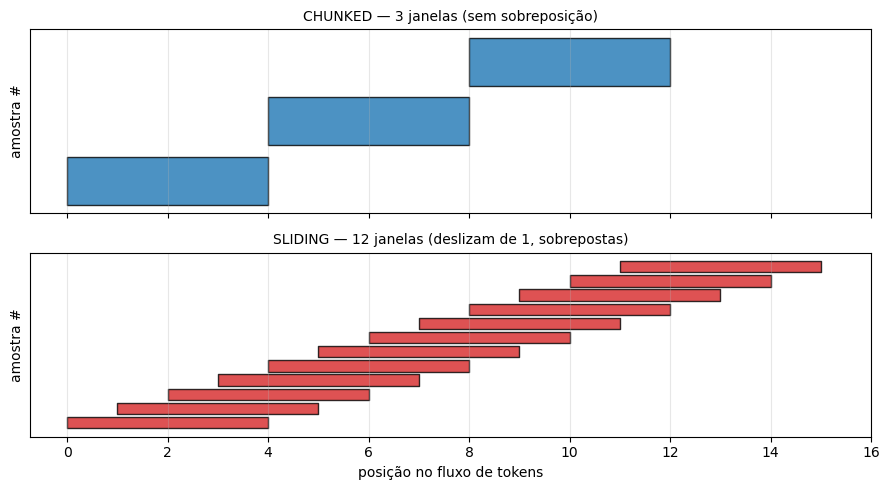

In [9]:
N_ill, ctx_ill = 16, 4
n_chunk = (N_ill - ctx_ill - 1) // ctx_ill + 1
n_slide = N_ill - ctx_ill

fig, (axc, axs) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
for ax, starts, titulo, cor in [
    (axc, range(0, n_chunk * ctx_ill, ctx_ill), f"CHUNKED — {n_chunk} janelas (sem sobreposição)", "C0"),
    (axs, range(0, n_slide), f"SLIDING — {n_slide} janelas (deslizam de 1, sobrepostas)", "C3"),
]:
    for row, s in enumerate(starts):
        ax.broken_barh([(s, ctx_ill)], (row, 0.8), facecolors=cor, alpha=0.8, edgecolor="k")
    ax.set_title(titulo, fontsize=10)
    ax.set_ylabel("amostra #"); ax.set_yticks([]); ax.grid(axis="x", alpha=0.3)
axs.set_xlabel("posição no fluxo de tokens"); axs.set_xticks(range(0, N_ill + 1, 2))
plt.tight_layout(); plt.show()

In [10]:
# y é SEMPRE x deslocado por 1 token — o contrato do next-token prediction.
x0, y0 = ds_chunked[0]
print("x[0] :", x0.tolist())
print("y[0] :", y0.tolist())
print("shapes:", tuple(x0.shape), tuple(y0.shape))

# x[i+1] == y[i] para todo i: o alvo da posição i é o próximo token.
assert torch.equal(x0[1:], y0[:-1]), "y deve ser x deslocado por 1"
# E a fronteira: y[t] é literalmente tokens[start+1+t]
assert torch.equal(y0, tokens[1:1 + T_ctx])
print("OK — y é x deslocado por 1 (next-token).")

x[0] : [82, 118, 98, 115, 108, 116, 33, 100]
y[0] : [118, 98, 115, 108, 116, 33, 100, 112]
shapes: (8,) (8,)
OK — y é x deslocado por 1 (next-token).


## 5. Cache de tokens: rápido, mas com uma armadilha (§6.3)

Tokenizar o corpus inteiro custa tempo (no paper, ~145 s por execução com o encoder
em C). Rodar isso a cada `train.py` é tempo morto. A solução é **cachear os tokens
em disco** (`torch.save` de um `LongTensor`) e recarregar em milissegundos.

A invalidação natural é por **mtime**: se o JSONL do corpus for mais novo que o
cache, re-tokeniza. Simples — e é onde mora o *pitfall*.

**A armadilha:** o cache depende de *duas* coisas — (1) o conteúdo do corpus e
(2) o tokenizer (o mapeamento texto → ids). O mtime só detecta mudança em (1). Se
você **retreina o tokenizer** mas o corpus continua o mesmo, o mtime não muda e o
cache fica **silenciosamente obsoleto**, com ids do tokenizer antigo. O modelo
treina em lixo sem nenhum erro aparente.

Duas saídas, da mais simples à mais robusta:
- **Convenção:** "ao retreinar o tokenizer, delete o cache explicitamente".
- **Estrutural:** guardar um *hash do tokenizer* no header do cache e validá-lo na
  leitura — assim o próprio código detecta a inconsistência. É o que fazemos abaixo.

In [11]:
def load_or_cache_corpus(jsonl_path, cache_path, encode_fn, tokenizer_id: str):
    """Carrega tokens do cache se válido; senão re-tokeniza e regrava.

    Validação robusta (§6.3): além do mtime, guardamos um hash/id do tokenizer no
    cache. Se qualquer um divergir, re-tokeniza. Isso fecha o buraco do 'retreinei
    o tokenizer mas o corpus não mudou'.
    """
    if os.path.exists(cache_path):
        blob = torch.load(cache_path)
        corpus_newer = os.path.getmtime(jsonl_path) > os.path.getmtime(cache_path)
        tok_changed = blob.get("tokenizer_id") != tokenizer_id
        if not corpus_newer and not tok_changed:
            return blob["tokens"]  # cache válido: hit em milissegundos
        # senão: cai fora do if e re-tokeniza abaixo
        reason = "corpus mudou" if corpus_newer else "tokenizer mudou"
        print(f"  cache inválido ({reason}) -> re-tokenizando")

    # (re)tokeniza
    ids = []
    with open(jsonl_path, encoding="utf-8") as f:
        for line in f:
            art = json.loads(line)
            ids.extend(encode_fn(art["text"]))
            ids.append(EOT)
    toks = torch.tensor(ids, dtype=torch.long)
    torch.save({"tokens": toks, "tokenizer_id": tokenizer_id}, cache_path)
    return toks

In [12]:
# Demonstração do pitfall em arquivos temporários (sem tocar em data/).
with tempfile.TemporaryDirectory() as d:
    jsonl = os.path.join(d, "corpus.jsonl")
    cache = os.path.join(d, "corpus_tokens.pt")
    with open(jsonl, "w", encoding="utf-8") as f:
        for art in mock_corpus:
            f.write(json.dumps({"text": art}) + "\n")

    # 1ª chamada: cache miss -> tokeniza com "tokenizer v1"
    t1 = load_or_cache_corpus(jsonl, cache, toy_encode, tokenizer_id="bpe-v1")
    print("1ª chamada (miss): ", t1.numel(), "tokens")

    # 2ª chamada, MESMO tokenizer: cache hit (nada muda, nem re-tokeniza)
    t2 = load_or_cache_corpus(jsonl, cache, toy_encode, tokenizer_id="bpe-v1")
    print("2ª chamada (hit):  ", t2.numel(), "tokens")
    assert torch.equal(t1, t2)

    # 3ª chamada: retreinei o tokenizer (id mudou) e o corpus é o MESMO.
    # Só o mtime NÃO detectaria isso. O hash do tokenizer detecta.
    t3 = load_or_cache_corpus(jsonl, cache, toy_encode, tokenizer_id="bpe-v2")
    print("3ª chamada:        ", t3.numel(), "tokens (re-tokenizou por causa do id)")
print("OK — cache válido em hit; re-tokeniza quando o tokenizer muda.")

1ª chamada (miss):  202 tokens
2ª chamada (hit):   202 tokens
  cache inválido (tokenizer mudou) -> re-tokenizando
3ª chamada:         202 tokens (re-tokenizou por causa do id)
OK — cache válido em hit; re-tokeniza quando o tokenizer muda.


## Resumo (o que carregar para o notebook 06)

| Peça | Decisão do paper | Onde vive no `src/` |
|---|---|---|
| Scraping | inglês (densidade técnica), JSONL por artigo | `data/scrape.py` |
| Rate limit | Δt ≥ 1,5 s + respeitar `Retry-After` | `data/scrape.py` |
| Limpeza | funções puras componíveis; descartar stubs <300 | `data/scrape.py` |
| `stride` do dataset | **chunked (stride = T_ctx)**, ~124× menos steps | `data/dataset.py` |
| `(x, y)` | `y` = `x` deslocado por 1 (next-token) | `data/dataset.py` |
| Cache | mtime **+ hash do tokenizer** (evita cache obsoleto) | `tokenizer/` + `data/` |

**A lição de método:** antes do `chunked dataset`, supôs-se que o limite era a
arquitetura ou o backend de compute. Era o *dataloader*. Meça onde o tempo
realmente vai antes de otimizar a peça errada.

**Caminho de evolução:** o próprio paper aponta (§9.3) que o próximo salto de
qualidade vem de **mais dados** (~100M tokens: `mC4-en`/OSCAR filtrados, Common
Crawl com filtro de qualidade), não de mais parâmetros — o regime Chinchilla que o
notebook 07 detalha.

Próximo: **`06_treinamento.ipynb`** — objetivo cross-entropy, AdamW com weight
decay separado, scheduler cosine+warmup, BF16, gradient clipping e early stopping.